The objective of this mini-project is to define and train a Conditional VAE
(CVAE)

D'après IBM : 

L’un des inconvénients des VAE « vanilla » classiques est que l’utilisateur n’a aucun contrôle sur les sorties spécifiques générées par l’auto-encodeur. Par exemple, un VAE classique entraîné à partir du jeu de données MNIST mentionné précédemment générera de nouveaux échantillons de chiffres manuscrits compris entre 0 et 9, mais il ne peut pas être contraint de ne produire que des 4 et des 7.

Comme leur nom l'indique, les VAE conditionnelles (CVAE) permettent d'obtenir des sorties conditionnées par des entrées spécifiques, plutôt que de générer uniquement des variations de données d'entraînement au hasard. Pour ce faire, des éléments d'apprentissage supervisé (ou semi-supervisé) sont incorporés aux objectifs de formation traditionnellement non supervisés des auto-encodeurs conventionnels.

En entraînant le modèle sur des exemples étiquetés de variables spécifiques, ces variables peuvent être utilisées pour conditionner la sortie du décodeur. Par exemple, un CVAE peut d'abord être entraîné sur un grand jeu de données d'images faciales, puis en utilisant l'apprentissage supervisé pour apprendre un codage latent pour les « barbes » afin qu'il puisse produire de nouvelles images de visages barbus.


des resssources pour le code et explication de ce que c'est

D'après https://medium.com/@mathparracho/variational-autoencoders-vaes-cvaes-%CE%B2-vaes-generative-intuition-practice-4b7b4011f55b

https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f

https://github.com/timbmg/VAE-CVAE-MNIST/blob/master/train.py

https://github.com/chendaichao/VAE-pytorch/blob/master/Models/VAE/Demo.ipynb

https://pyro.ai/examples/cvae.html

https://deepwiki.com/gozsoy/conditional-vae/3.2-conditional-vae-architecture

https://github.com/unnir/cVAE


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Importation des datas

In [2]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='data_cvae', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='data_cvae', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# To save fig
figures_path = 'figures/'

# Hyperparameters
batch_size = 128
latent_dim = 2
learning_rate = 1e-3
epochs = 5
kl_weights = [1, 10, 100]  # Different weights for the KL divergence term

# To save the plots
name = 'batch_size_'+str(batch_size)+'_latent_dim_'+str(latent_dim)+'_learning_rate_'+str(learning_rate)+'_epochs_'+str(epochs)


Début de fonction pour créer des CNN avec une profondeur différentes et créer des couches plus rapidement

In [4]:
def construct_CNN(couches_conv:list):
    nn.Conv2d(1, couches_conv[0], kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
    nn.BatchNorm2d(couches_conv[0]),
    nn.ReLU(),
    for i in range(1,len(couches_conv)):
        print(i)
        nn.Conv2d(couches_conv[i-1], couches_conv[i], kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
        nn.BatchNorm2d(couches_conv[i]),
        nn.ReLU(),

encoder = nn.Sequential(construct_CNN([32,64,128]))
print(encoder)

1
2
Sequential(
  (0): None
)


Pour l'instant, on a simplement repris le convolutional vae du tp et transformé en conditional.
Il a fallut rajouter un vecteur des labels, les labels étant le y de la probabilité conditionnelle.

In [ ]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_embedding = nn.Embedding(10, 16) # sert à créer un vecteur des labels
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_logvar = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + 16, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, y):
        x = self.encoder(x)
        x = x.view(-1, 128 * 4 * 4) # Flatten the output of the convolutional layers
        y = self.label_embedding(y)
        mu = self.fc_mu(torch.cat((x,y),dim=1))
        logvar = self.fc_logvar(torch.cat((x,y),dim=1))
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, y, hot_shot = False):
        if hot_shot == False:              # to generate samples
            y = self.label_embedding(y) 
        x = self.fc_decode(torch.cat((z,y),dim=1))
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar 
    


utilisation des la même loss que pour les vae, on fait varier le coefficient beta

In [6]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD


Training VAE with KL Weight = 1
Epoch 1, Training loss: 274.7694
Epoch 2, Training loss: 258.3544
Epoch 3, Training loss: 256.6398
Epoch 4, Training loss: 255.4888
Epoch 5, Training loss: 254.8351


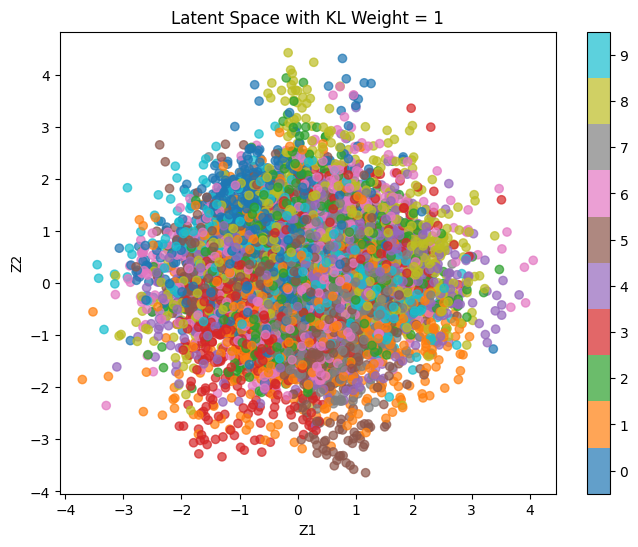

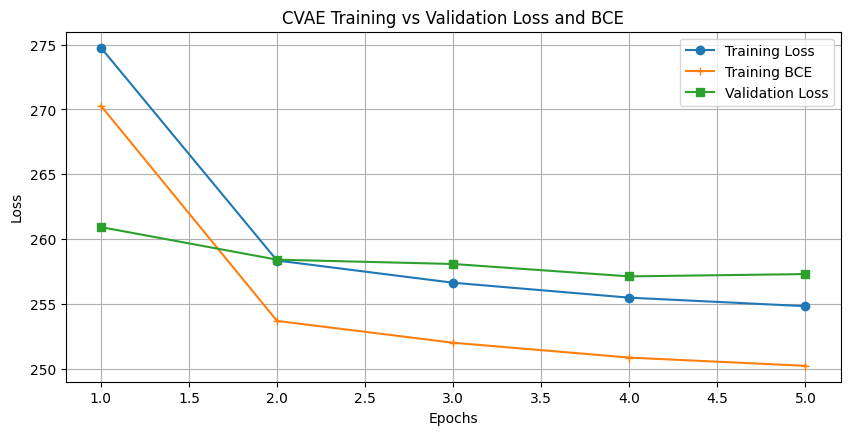

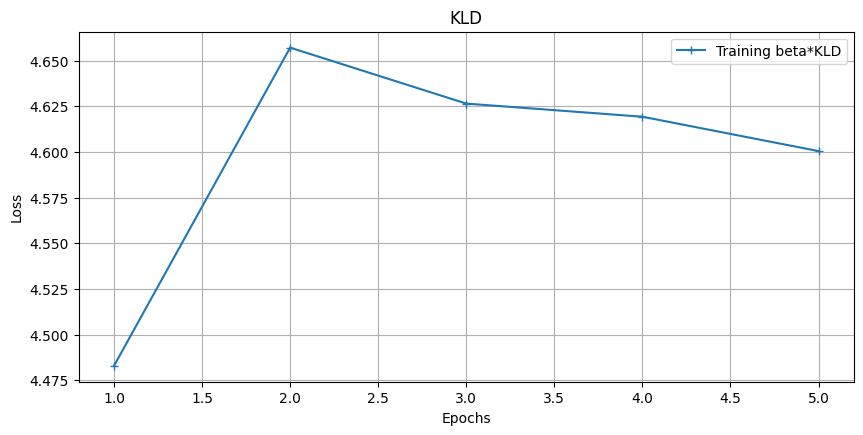


Training VAE with KL Weight = 10
Epoch 1, Training loss: 280.1908
Epoch 2, Training loss: 279.0494
Epoch 3, Training loss: 278.6764
Epoch 4, Training loss: 278.4810
Epoch 5, Training loss: 278.3322


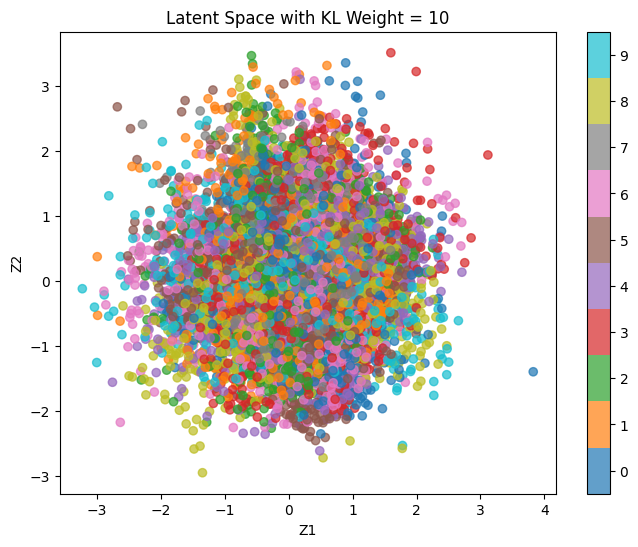

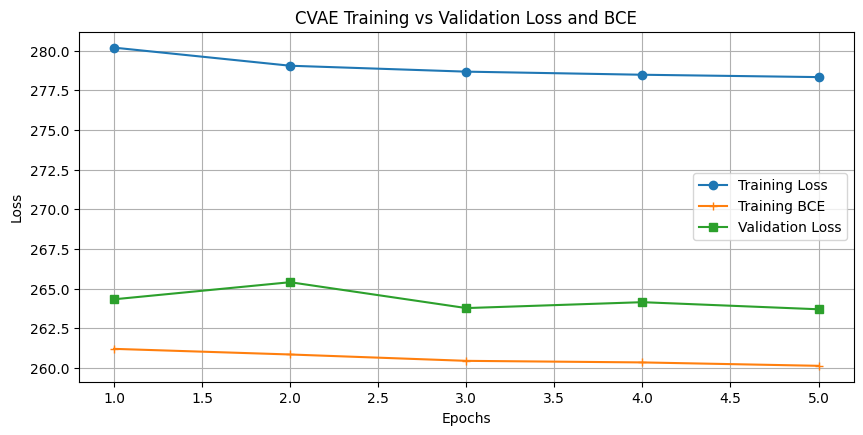

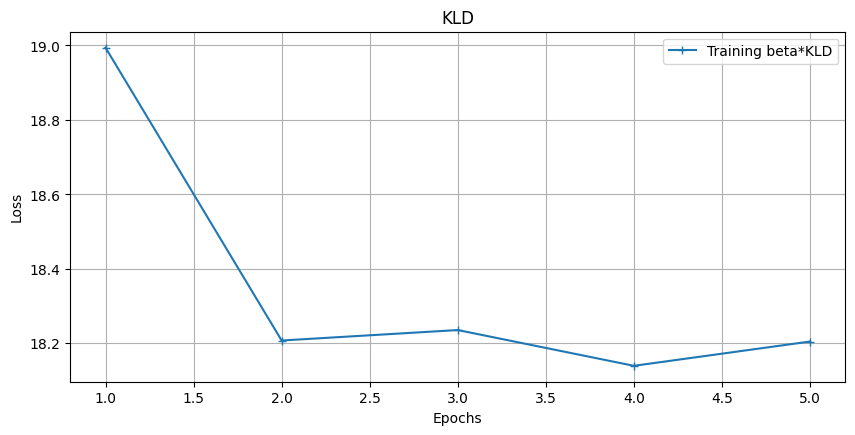


Training VAE with KL Weight = 100
Epoch 1, Training loss: 311.8650
Epoch 2, Training loss: 307.7309
Epoch 3, Training loss: 307.5395
Epoch 4, Training loss: 307.4716
Epoch 5, Training loss: 307.4505


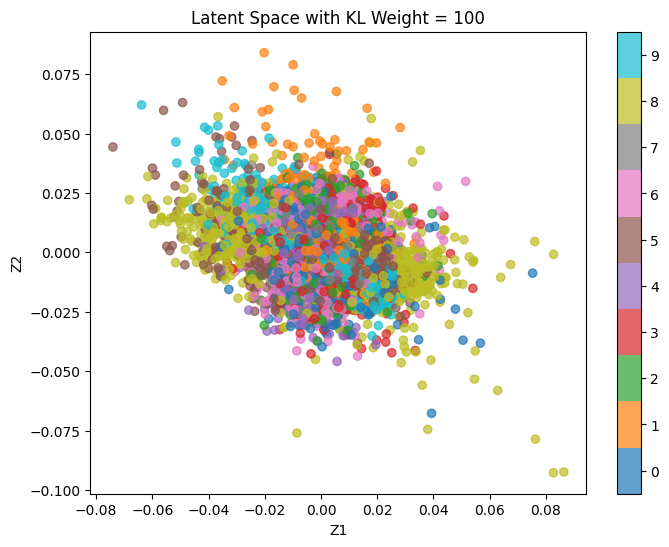

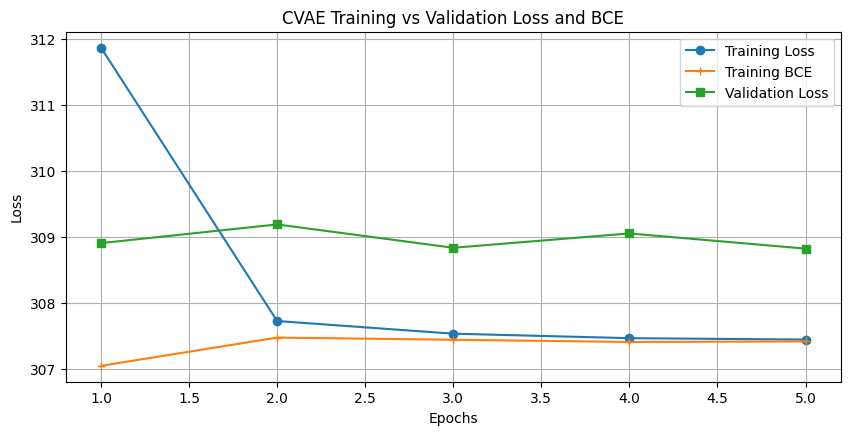

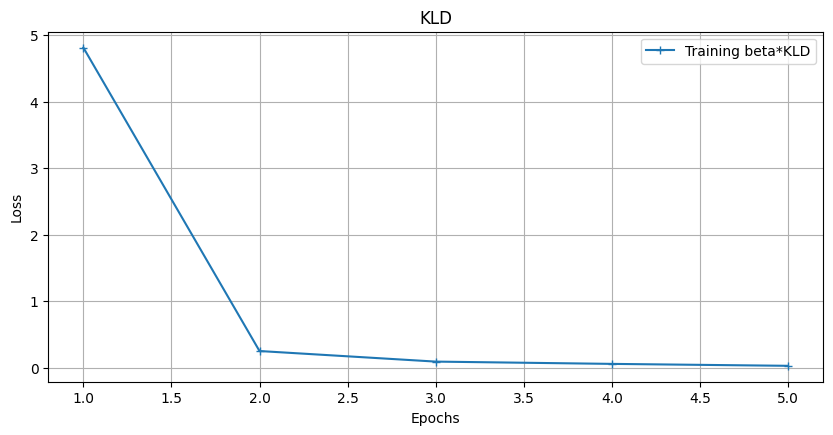

In [15]:

# Initialize the CVAE model and the Adam optimizer
cvae = ConditionalVAE(latent_dim=latent_dim)
cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)

def plot_loss(epochs, losses, BCE, kl_weight, KLD, val_losses, figures_path, name):
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 1, 1)
    #plt.figure(figsize=(8,5))
    plt.plot(range(1, epochs+1), losses, marker='o', label='Training Loss')
    plt.plot(range(1, epochs+1), BCE, marker='+', label='Training BCE')
    plt.plot(range(1, epochs+1), val_losses, marker='s', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('CVAE Training vs Validation Loss and BCE')
    plt.legend()
    plt.grid(True)
    file_name = 'plot_loss_function' + name +'.png'
    file_path = figures_path + file_name
    plt.savefig(file_path)
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.subplot(2, 1, 2)
    second_terme = [KLD[i]*kl_weight for i in range(len(KLD))]
    #for i in range(len(KLD)) :
    #    second_terme.append(KLD[i]*kl_weight)
    plt.plot(range(1, epochs+1), second_terme, marker='+', label='Training beta*KLD')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('KLD')
    plt.legend()
    plt.grid(True)
    file_name = 'plot_beta_kld' + name +'.png'
    file_path = figures_path + file_name
    plt.savefig(file_path)
    plt.show()

# Function to plot latent space
def plot_latent_space(model, kl_weight, figure_path, name):
    model.eval()
    with torch.no_grad():
        test_loader = DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)
        data, labels = next(iter(test_loader))
        data = data.to(device)
        label = labels.to(device)
        mu, logvar = model.encode(data, label)
        z = mu  # For visualization, we use the mean
        z = z.cpu().numpy()
        labels = labels.numpy()
        
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', alpha=0.7)
        plt.colorbar(scatter, ticks=range(10))
        plt.clim(-0.5, 9.5)
        plt.title(f'Latent Space with KL Weight = {kl_weight}')
        plt.xlabel('Z1')
        plt.ylabel('Z2')
        file_name = 'plot_latent_space_'+ name
        file_path = figure_path + file_name + '_kl_weight_'+str(kl_weight)+'.png'
        plt.savefig(file_path)
        plt.show()

# Train the model for the given number of epochs
# At the end of each epoch, print the training loss



for kl_weight in kl_weights :
    print(f'\nTraining VAE with KL Weight = {kl_weight}')

    losses = []  # liste pour stocker les pertes
    BCE = []
    KLD = []
    val_losses = [] # liste pour stocker la validation loss

    for epoch in range(1, epochs + 1):
        cvae.train()
        running_loss = 0.0
        running_bce = 0.0
        running_kld = 0.0

        for batch_idx, (data, label) in enumerate(train_loader): # label c'est le y
            data = data.to(device)
            label = label.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = cvae(data, label)
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar, kl_weight)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_bce += bce.item()
            running_kld += kld.item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_bce = running_bce / len(train_loader.dataset)
        epoch_kld = running_kld / len(train_loader.dataset)

        losses.append(epoch_loss)  # on sauvegarde la perte
        BCE.append(epoch_bce)
        KLD.append(epoch_kld)


        # --- Validation ---
        cvae.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch, mu, logvar = cvae(data, label)
                val_loss, _, _ = loss_function(recon_batch, data, mu, logvar)
                val_running_loss += val_loss.item()
        
        epoch_val_loss = val_running_loss / len(test_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')
    plot_latent_space(cvae, kl_weight, figures_path, name)
    plot_loss(epochs, losses, BCE, kl_weight, KLD, val_losses, figures_path, name)



In [8]:
import matplotlib.pyplot as plt

def image_comparison(original_images, reconstructions, n_images=6):
    """Plots the original images and its reconstructions for comparison

    Args:
        original_image (torch.Tensor): The original images
        reconstructions (torch.Tensor): Reconstruction of the original images
    """
    fig, ax = plt.subplots(2, n_images, figsize=(20, 7))
    
    for i in range(n_images):
        # Plot original images
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, 0].set_title('Original')

        # Reconstructed images
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')
        ax[1, 0].set_title('Recomstruction')
    
    plt.tight_layout()
    file_name = 'image_comparison' + name+'.png'
    file_path = figures_path + file_name
    plt.savefig(file_path)
    plt.show()

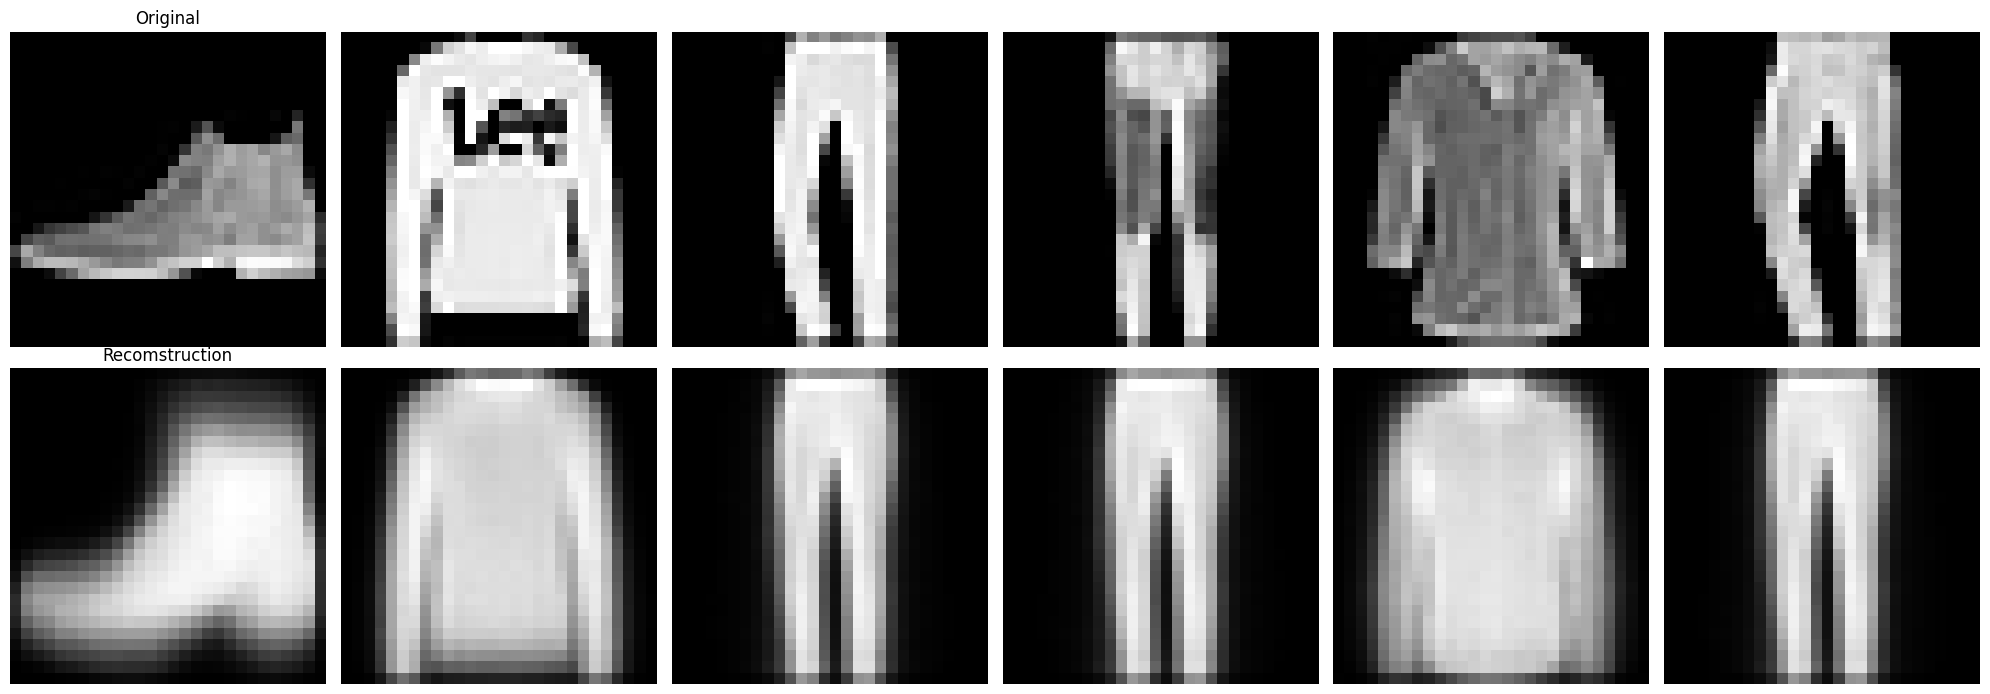

In [9]:
# Select a batch of images from the test dataset
random_images = next(iter(test_loader))

# Get the reconstructions of the selected images
recons, _, _ = cvae(random_images[0].to(device),random_images[1].to(device))

# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons = recons.detach().cpu().numpy().squeeze()

# Plot the original images and their reconstructions
image_comparison(random_images, recons)

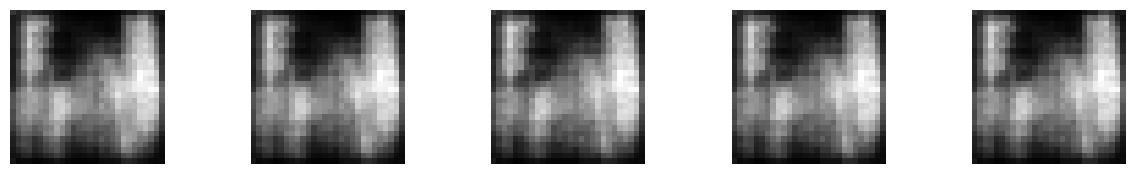

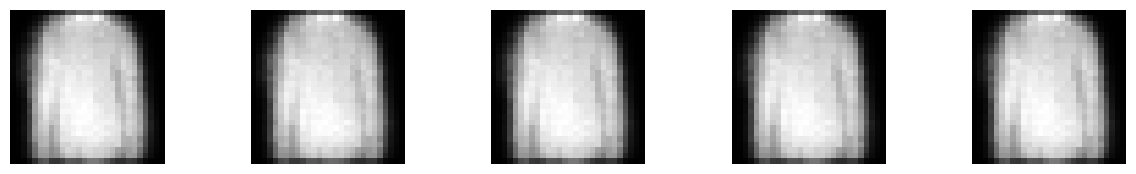

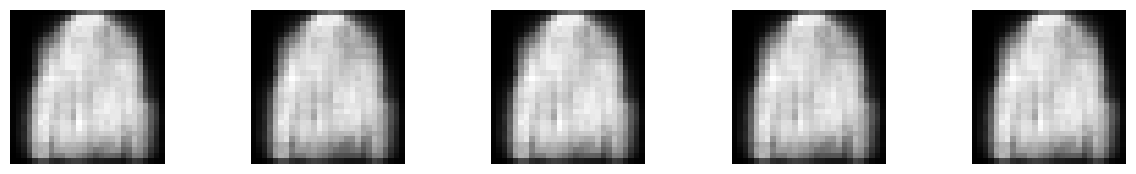

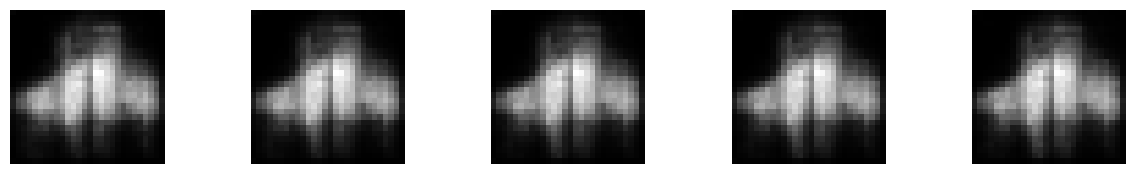

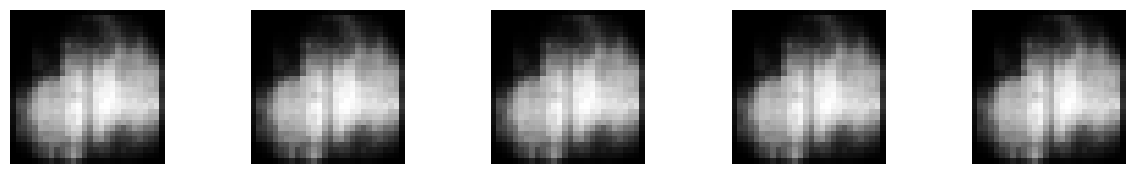

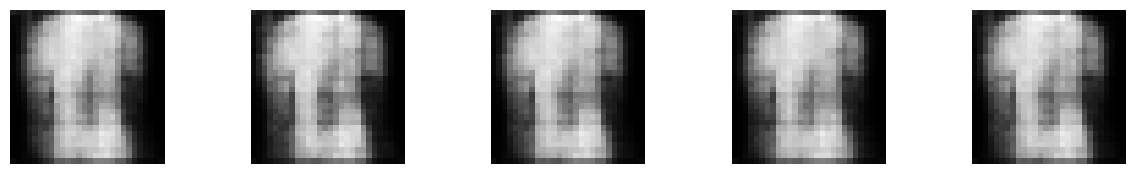

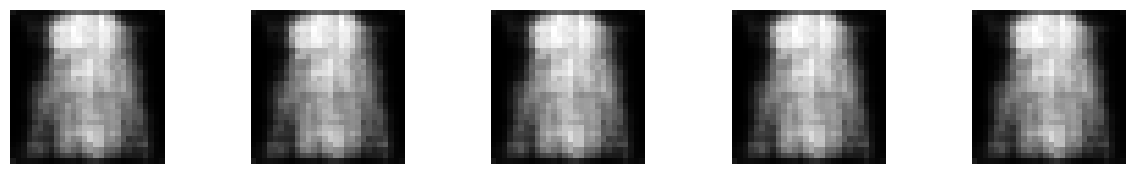

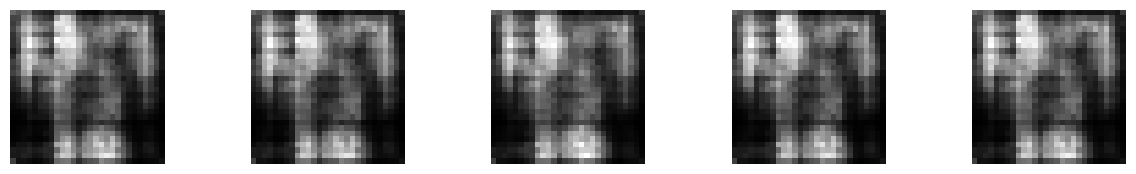

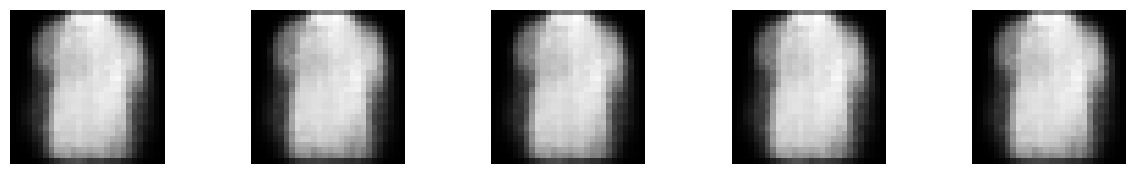

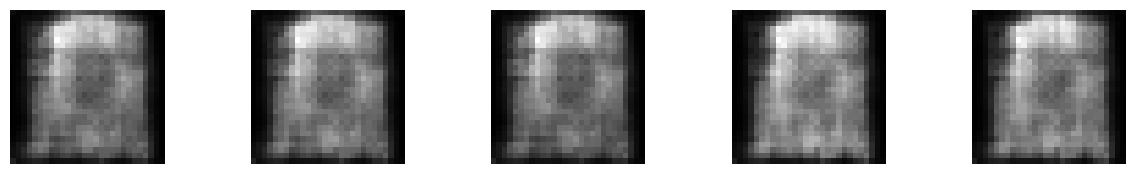

In [10]:
def generate_sample(num_samples=5):
    cvae.eval()
    with torch.no_grad():
        for i in range(10):
            random_samples = torch.randn(num_samples, latent_dim).to(device)
            label_embedding = nn.Embedding(10, 16)
            label = label_embedding(torch.tensor([i,i,i,i,i])).to(device)
            samples = cvae.decode(random_samples, label, hot_shot = True)
            samples = samples.cpu().view(num_samples, 1, 28, 28) # Reshape the samples

            fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
            for i in range(num_samples):
                ax[i].imshow(samples[i].squeeze(0), cmap='gray')
                ax[i].axis('off')

            file_name = 'generated_samples' + name + str(i)+'.png'
            file_path = figures_path + file_name
            plt.savefig(file_path)
            plt.show()

generate_sample()